# OptiVest Optimization Methodology Walkthrough

This notebook demonstrates the actual Phase 4 optimization engine: a transparent five-stock worked example, continuous quadratic optimization, cardinality-constrained PuLP optimization, and the real 49-stock efficient frontier. It imports the production solvers and analytics frontier service directly; no optimization formula is duplicated in notebook code.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sqlalchemy import select, func, and_
from sqlalchemy.ext.asyncio import async_sessionmaker

REPO_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "backend" / "app").is_dir()
)
BACKEND_ROOT = REPO_ROOT / "backend"
if str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))
os.chdir(BACKEND_ROOT)

from app.core.config import get_settings
from app.db.session import create_engine

SETTINGS = get_settings()
ENGINE = create_engine()
SessionLocal = async_sessionmaker(ENGINE, expire_on_commit=False, autoflush=False)

sns.set_theme(style="whitegrid", context="notebook")
OPTIVEST = {"navy": "#14213D", "teal": "#00A896", "gold": "#FCA311", "red": "#D1495B"}
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"Repository: {REPO_ROOT}")
print(f"Database configured by app.core.config: {SETTINGS.database_url.split('@')[-1]}")

Repository: P:\Placement\Projects\Github Projects\IT\OR-OptiVest
Database configured by app.core.config: localhost:5433/optivest


## Five-stock worked example

The fixture is the version-controlled Phase 4 reference universe. Expected returns and the diagonal covariance matrix are displayed before solving so the numerical inputs remain auditable.

In [2]:
import json
from dataclasses import replace

from app.optimization.pulp_solver import solve_mad
from app.optimization.scipy_solver import solve_continuous
from app.optimization.types import OptimizationInput, SolverName

fixture_path = BACKEND_ROOT / "tests" / "optimization" / "fixtures" / "five_stock_universe.json"
fixture = json.loads(fixture_path.read_text(encoding="utf-8"))
symbols = tuple(fixture["symbols"])
expected_returns = np.asarray(fixture["expected_returns"], dtype=float)
annualized_volatility = np.asarray(fixture["annualized_volatility"], dtype=float)
covariance = np.diag(annualized_volatility ** 2)

input_table = pd.DataFrame({
    "symbol": symbols,
    "expected_return": expected_returns,
    "annualized_volatility": annualized_volatility,
    "sector": fixture["sectors"],
})
display(input_table.style.format({"expected_return": "{:.2%}", "annualized_volatility": "{:.2%}"}))
display(pd.DataFrame(covariance, index=symbols, columns=symbols).style.format("{:.6f}"))

,symbol,expected_return,annualized_volatility,sector
0,RELIANCE,14.00%,22.00%,Energy
1,TCS,16.00%,18.00%,IT
2,HDFCBANK,13.00%,16.00%,Financials
3,INFY,17.00%,21.00%,IT
4,ITC,11.00%,14.00%,FMCG


,RELIANCE,TCS,HDFCBANK,INFY,ITC
RELIANCE,0.048400,0.000000,0.000000,0.000000,0.000000
TCS,0.000000,0.032400,0.000000,0.000000,0.000000
HDFCBANK,0.000000,0.000000,0.025600,0.000000,0.000000
INFY,0.000000,0.000000,0.000000,0.044100,0.000000
ITC,0.000000,0.000000,0.000000,0.000000,0.019600


## Continuous QP and cardinality-constrained model

The SciPy solve minimizes portfolio variance subject to the return floor, budget, non-negativity, single-stock, and sector constraints. The PuLP solve activates the minimum/maximum holdings and minimum-lot linking constraints and minimizes mean absolute deviation under the same allocation rules.

,symbol,SciPy QP,PuLP cardinality
0,RELIANCE,12.95%,6.67%
1,TCS,22.26%,40.00%
2,HDFCBANK,22.63%,40.00%
3,INFY,17.43%,0.00%
4,ITC,24.73%,13.33%


,model,expected_return,volatility,solve_time_ms
0,SciPy QP,14.00%,7.92%,31
1,PuLP cardinality/MAD,14.00%,9.92%,681


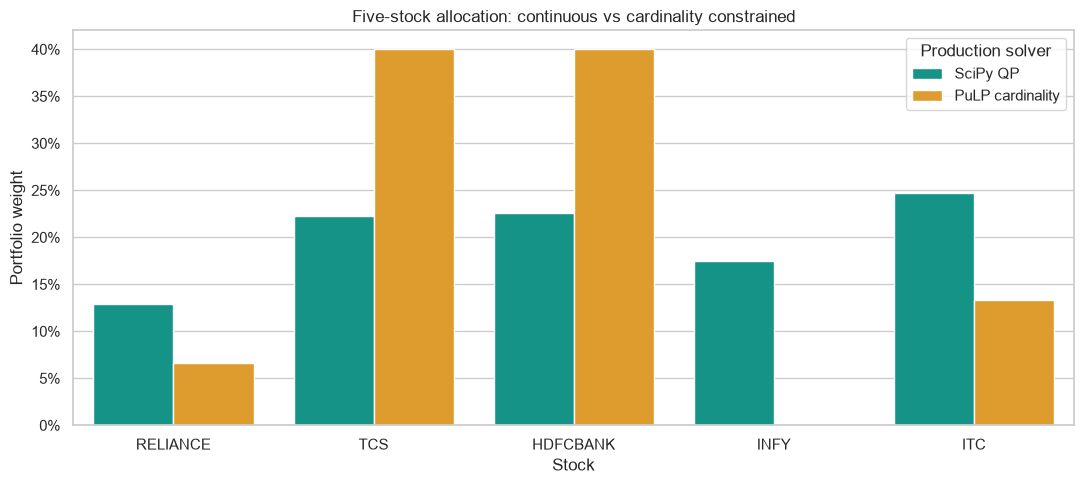

In [3]:
shared_problem = OptimizationInput(
    symbols=symbols,
    expected_returns=expected_returns,
    covariance=covariance,
    sectors=tuple(fixture["sectors"]),
    budget=float(fixture["budget_inr"]),
    target_return=float(fixture["target_return"]),
    max_single_weight=float(fixture["max_single_weight"]),
    sector_caps={key: float(value) for key, value in fixture["sector_caps"].items()},
    default_sector_cap=float(fixture["default_sector_cap"]),
    min_holdings=None,
    max_holdings=None,
    min_lot_weight=float(fixture["min_lot_weight"]),
    solver=SolverName.SCIPY,
)
qp_result = solve_continuous(shared_problem)
milp_problem = replace(
    shared_problem,
    min_holdings=int(fixture["min_holdings"]),
    max_holdings=int(fixture["max_holdings"]),
    solver=SolverName.PULP,
)
milp_result = solve_mad(milp_problem)
assert qp_result.is_feasible and milp_result.is_feasible

comparison_df = pd.DataFrame({
    "symbol": symbols,
    "SciPy QP": [qp_result.weights[symbol] for symbol in symbols],
    "PuLP cardinality": [milp_result.weights[symbol] for symbol in symbols],
})
display(comparison_df.style.format({"SciPy QP": "{:.2%}", "PuLP cardinality": "{:.2%}"}))
display(pd.DataFrame([
    {"model": "SciPy QP", "expected_return": qp_result.expected_return, "volatility": qp_result.expected_volatility, "solve_time_ms": qp_result.solve_time_ms},
    {"model": "PuLP cardinality/MAD", "expected_return": milp_result.expected_return, "volatility": milp_result.expected_volatility, "solve_time_ms": milp_result.solve_time_ms},
]).style.format({"expected_return": "{:.2%}", "volatility": "{:.2%}"}))

allocation_long = comparison_df.melt("symbol", var_name="model", value_name="weight")
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=allocation_long, x="symbol", y="weight", hue="model", palette=[OPTIVEST["teal"], OPTIVEST["gold"]], ax=ax)
ax.set(title="Five-stock allocation: continuous vs cardinality constrained", xlabel="Stock", ylabel="Portfolio weight")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Production solver")
fig.tight_layout()
plt.show()

## Real 49-stock efficient frontier

The notebook reads the latest persisted 252-observation covariance cache and latest solved optimization record. The frontier uses the production SciPy sweep on the continuous relaxation; the persisted portfolio point is overlaid separately because its cardinality constraints make it a discrete solution.

Cache 09282fd9-3226-4d19-b950-b46398dd3b02: 2026-01-30, 252 observations, 49 stocks
Frontier points returned: 30


,expected_return,volatility
0,0.0764,0.0933
1,0.0886,0.0934
2,0.1008,0.0935
3,0.1130,0.0937
4,0.1252,0.0940


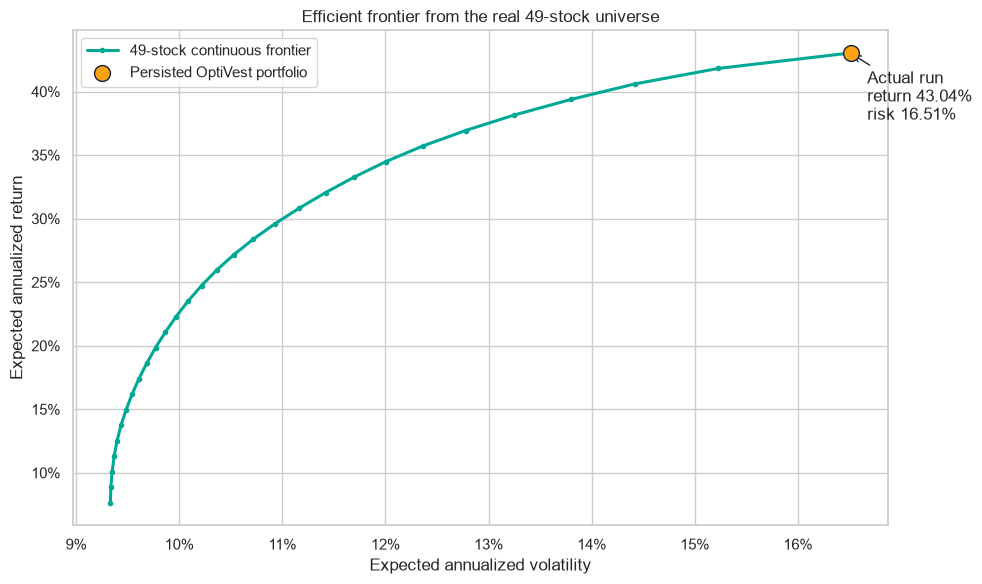

In [4]:
from app.analytics.efficient_frontier import build_efficient_frontier
from app.db.models import CovarianceCache, OptimizationRun, PortfolioSnapshot, Sector, Stock
from app.services.problem_service import decode_constraint_config

async with SessionLocal() as session:
    cache_candidates = (await session.scalars(
        select(CovarianceCache)
        .where(CovarianceCache.lookback_days == SETTINGS.covariance_lookback_days)
        .order_by(CovarianceCache.as_of_date.desc(), CovarianceCache.computed_at.desc())
    )).all()
    real_cache = next(cache for cache in cache_candidates if len(cache.matrix.get("symbols", [])) == 49)
    latest_run = await session.scalar(
        select(OptimizationRun)
        .where(OptimizationRun.status == "solved")
        .order_by(OptimizationRun.run_at.desc())
        .limit(1)
    )
    assert latest_run is not None
    actual_snapshot = await session.scalar(
        select(PortfolioSnapshot)
        .where(PortfolioSnapshot.optimization_run_id == latest_run.id)
        .order_by(PortfolioSnapshot.created_at.desc())
        .limit(1)
    )
    sector_rows = (await session.execute(
        select(Stock.symbol, Sector.name)
        .join(Sector, Sector.id == Stock.sector_id)
        .where(Stock.symbol.in_(tuple(real_cache.matrix["symbols"])))
    )).all()

assert actual_snapshot is not None
sector_by_symbol = dict(sector_rows)
real_symbols = tuple(real_cache.matrix["symbols"])
config = decode_constraint_config(latest_run.sector_constraints)
real_problem = OptimizationInput(
    symbols=real_symbols,
    expected_returns=np.asarray(real_cache.matrix["expected_returns"], dtype=float),
    covariance=np.asarray(real_cache.matrix["covariance"], dtype=float),
    sectors=tuple(sector_by_symbol[symbol] for symbol in real_symbols),
    budget=float(latest_run.budget),
    target_return=float(latest_run.target_return) if latest_run.target_return is not None else None,
    risk_tolerance=float(latest_run.risk_tolerance) if latest_run.risk_tolerance is not None else None,
    max_single_weight=float(latest_run.max_single_weight),
    sector_caps=config["caps"],
    default_sector_cap=config["default_sector_cap"],
    min_holdings=None,
    max_holdings=None,
    min_lot_weight=config["min_lot_weight"],
    historical_returns=np.asarray(real_cache.matrix["historical_returns"], dtype=float),
    solver=SolverName.SCIPY,
    risk_free_rate=config["risk_free_rate"],
)
frontier = build_efficient_frontier(real_problem, point_count=30)
frontier_df = pd.DataFrame({
    "expected_return": [point.expected_return for point in frontier],
    "volatility": [point.volatility for point in frontier],
})
print(f"Cache {real_cache.id}: {real_cache.as_of_date}, {real_cache.lookback_days} observations, {len(real_symbols)} stocks")
print(f"Frontier points returned: {len(frontier_df)}")
display(frontier_df.head())

actual_return = float(actual_snapshot.expected_return)
actual_volatility = float(actual_snapshot.expected_volatility)
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frontier_df["volatility"], frontier_df["expected_return"], color=OPTIVEST["teal"], linewidth=2.2, marker="o", markersize=3, label="49-stock continuous frontier")
ax.scatter([actual_volatility], [actual_return], color=OPTIVEST["gold"], edgecolor=OPTIVEST["navy"], s=130, zorder=5, label="Persisted OptiVest portfolio")
ax.annotate(f"Actual run\nreturn {actual_return:.2%}\nrisk {actual_volatility:.2%}", (actual_volatility, actual_return), xytext=(12, -48), textcoords="offset points", arrowprops={"arrowstyle": "->", "color": OPTIVEST["navy"]})
ax.set(title="Efficient frontier from the real 49-stock universe", xlabel="Expected annualized volatility", ylabel="Expected annualized return")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend()
fig.tight_layout()
plt.show()

In [5]:
await ENGINE.dispose()
print("Database engine disposed; optimization demonstrations were not persisted.")

Database engine disposed; optimization demonstrations were not persisted.


## Key takeaway

The same production components support both a small, inspectable worked example and the real universe. Cardinality changes the feasible allocation set and risk measure, while the real frontier shows the risk-return trade-off surrounding an actual persisted OptiVest decision.